# Initial Data Exploration
## Imports and load raw_data

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_parquet("../../energy-demand-forecasting/data/raw/raw_data.parquet")
df

,cod_areacarga,dat_referencia,din_referenciautc,val_cargaglobalprogramada
0,SECO,2025-01-01,2025-01-01T03:30:00.000Z,35972.086
1,SECO,2025-01-01,2025-01-01T04:00:00.000Z,35932.860
2,SECO,2025-01-01,2025-01-01T04:30:00.000Z,35742.830
3,SECO,2025-01-01,2025-01-01T05:00:00.000Z,35519.805
4,SECO,2025-01-01,2025-01-01T05:30:00.000Z,35236.580
...,...,...,...,...
53707,S,2025-10-06,2025-10-07T01:00:00.000Z,14587.437
53708,S,2025-10-06,2025-10-07T01:30:00.000Z,14104.245
53709,S,2025-10-06,2025-10-07T02:00:00.000Z,13528.004
53710,S,2025-10-06,2025-10-07T02:30:00.000Z,12792.284


## Describe (distribution and count nan values)
### raw_data

In [7]:
df.describe()

,val_cargaglobalprogramada
count,53712.000000
mean,19901.334929
std,14821.179668
min,6252.126500
25%,9291.691750
50%,13542.031500
75%,20508.809250
max,62017.258000


### separated by area

In [10]:
df_wide = df.pivot(
    index=["dat_referencia", "din_referenciautc"],
    columns="cod_areacarga",
    values="val_cargaglobalprogramada"
).reset_index()

df_wide.columns.name = None

df_wide

,dat_referencia,din_referenciautc,N,NE,S,SECO
0,2025-01-01,2025-01-01T03:30:00.000Z,6993.9233,13055.296,10969.760,35972.086
1,2025-01-01,2025-01-01T04:00:00.000Z,7045.5444,13095.554,10975.536,35932.860
2,2025-01-01,2025-01-01T04:30:00.000Z,7074.0435,13115.716,11007.457,35742.830
3,2025-01-01,2025-01-01T05:00:00.000Z,7148.4460,13141.099,10944.367,35519.805
4,2025-01-01,2025-01-01T05:30:00.000Z,7171.9277,13166.489,10790.524,35236.580
...,...,...,...,...,...,...
13627,2025-10-11,2025-10-12T01:00:00.000Z,9110.2070,NaN,NaN,NaN
13628,2025-10-11,2025-10-12T01:30:00.000Z,9095.2705,NaN,NaN,NaN
13629,2025-10-11,2025-10-12T02:00:00.000Z,9141.5600,NaN,NaN,NaN
13630,2025-10-11,2025-10-12T02:30:00.000Z,9132.9350,NaN,NaN,NaN


In [11]:
df_wide.describe()

,N,NE,S,SECO
count,13584.000000,13440.000000,13392.000000,13296.000000
mean,8111.597302,13287.122812,13918.575928,44658.247936
std,637.034226,1185.756754,2790.107841,6520.465714
min,6252.126500,9417.414000,7956.782700,30012.906000
25%,7662.410450,12452.305000,11646.009250,39660.280000
50%,8096.367800,13365.749000,14076.483000,44744.543000
75%,8517.707000,14203.711000,15714.406250,49327.464000
max,10172.481000,16724.203000,22474.654000,62017.258000


## Dataviz

In [18]:
cols = ["N", "NE", "S", "SECO"]

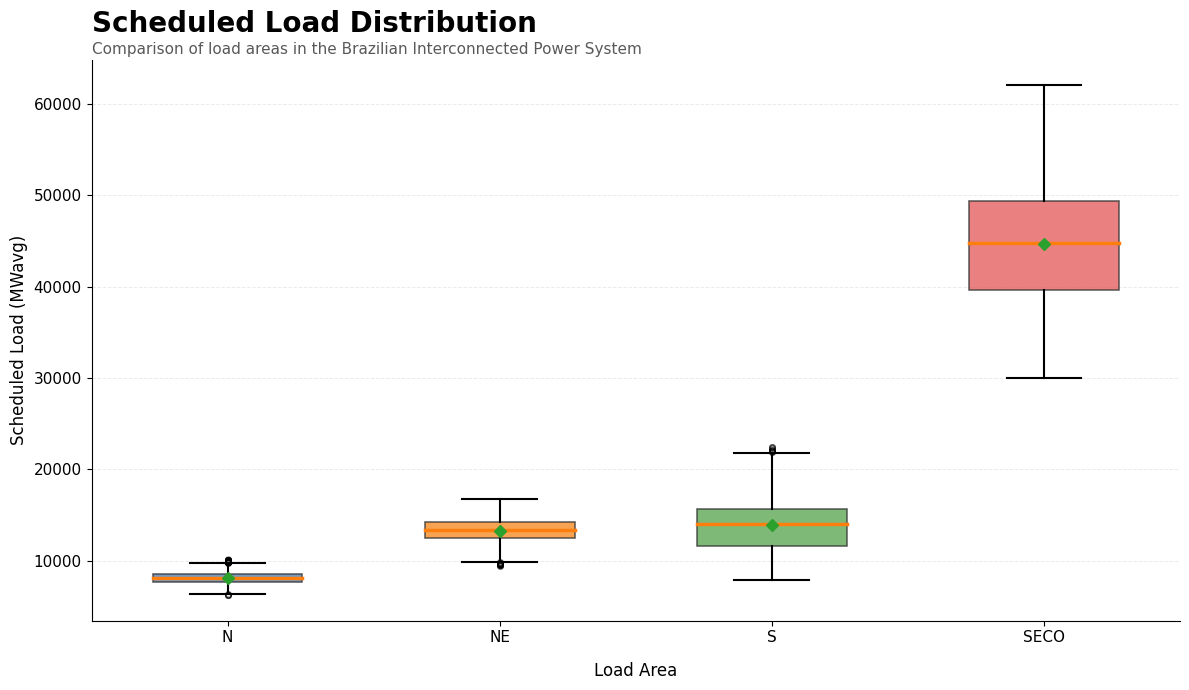

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

data = [df_wide[c].dropna() for c in cols]

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    showmeans=True,
    labels=cols,

    medianprops={
        "linewidth": 2.5,
    },

    meanprops={
        "marker": "D",
        "markersize": 6,
        "markeredgewidth": 1,
    },

    whiskerprops={
        "linewidth": 1.5,
    },

    capprops={
        "linewidth": 1.5,
    },

    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.3,
    },
)

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("#333333")
    patch.set_linewidth(1.2)

ax.set_title(
    "Scheduled Load Distribution",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Comparison of load areas in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.set_xlabel(
    "Load Area",
    fontsize=12,
    labelpad=12,
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=11,
)

plt.tight_layout()
plt.show()

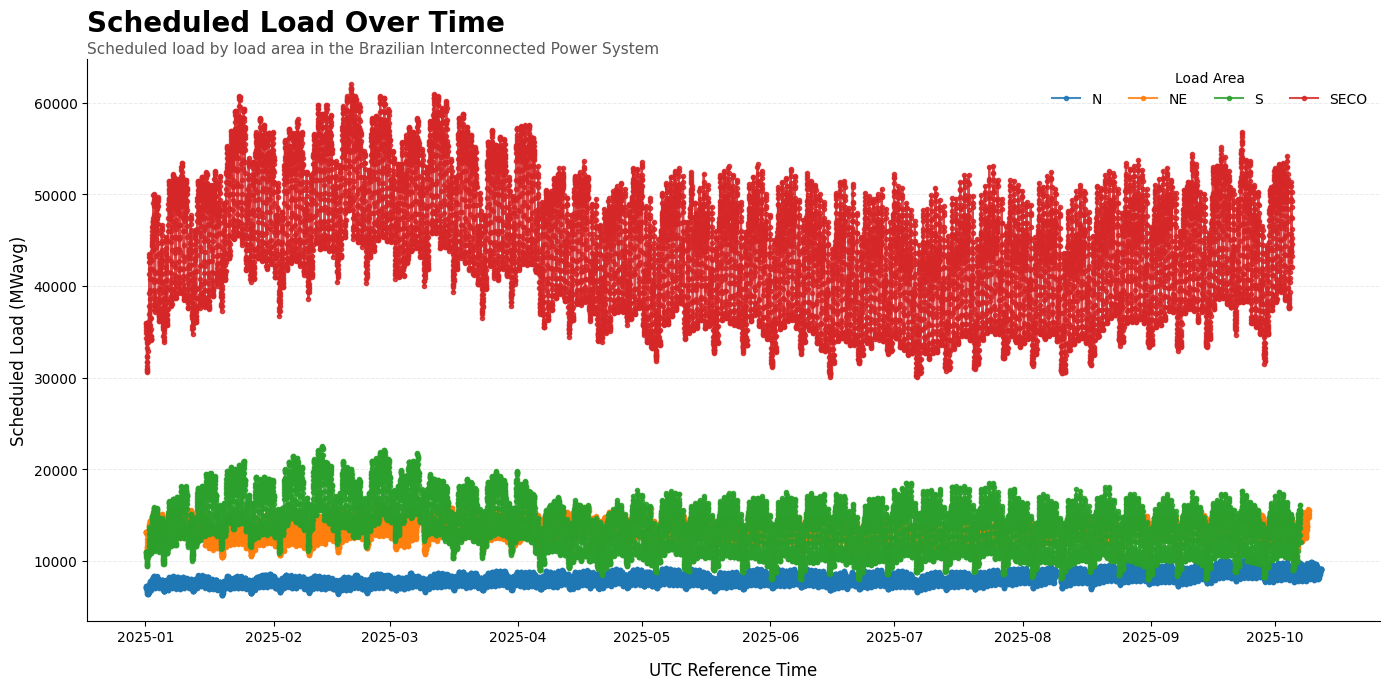

In [ ]:
df_wide["din_referenciautc"] = pd.to_datetime(
    df_wide["din_referenciautc"]
)

df_plot = df_wide.sort_values("din_referenciautc")

fig, ax = plt.subplots(figsize=(14, 7))

for area in cols:
    ax.plot(
        df_plot["din_referenciautc"],
        df_plot[area],
        marker="o",
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
        label=area,
    )

ax.set_title(
    "Scheduled Load Over Time",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Scheduled load by load area in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_xlabel(
    "UTC Reference Time",
    fontsize=12,
    labelpad=12,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Load Area",
    frameon=False,
    ncol=4,
)

plt.tight_layout()
plt.show()